# 04 - Statistical Analysis
## Retail Analytics | SectionB Group 3
### Covers: Hypothesis Testing, Regression, Forecasting, Segmentation

In [1]:
from pathlib import Path
PROJECT_ROOT = Path('.').resolve().parent
INPUT_PATH = PROJECT_ROOT / 'data' / 'processed' / 'cleaned_dataset.csv'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLEAU_READY_PATH = PROJECT_ROOT / 'data' / 'processed' / 'tableau_ready_data.csv'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/cleaned_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
print("Data loaded. Shape:", df.shape)
print(df.head())


Data loaded. Shape: (302006, 35)
   Transaction_ID  Customer_ID        City            State    Country   Age  \
0       8691788.0      37249.0    Dortmund           Berlin    Germany  21.0   
1       2174773.0      69749.0  Nottingham          England         UK  19.0   
2       6679610.0      30192.0     Geelong  New South Wales  Australia  48.0   
3       7232460.0      62101.0    Edmonton          Ontario     Canada  56.0   
4       4983775.0      27901.0     Bristol          England         UK  22.0   

   Gender Income Customer_Segment       Date  ...  avg_order_value age_group  \
0    Male    Low          Regular 2023-09-18  ...       108.028757     Young   
1  Female    Low          Premium 2023-12-31  ...       403.353907     Young   
2    Male    Low          Regular 2023-04-26  ...       354.477600    Senior   
3    Male   High          Premium 2023-05-08  ...       352.407717    Senior   
4    Male    Low          Premium 2024-01-10  ...       124.276525     Young   

  pur

## 1. Hypothesis Testing

### Test 1: Do Premium customers spend more than Regular customers?
**Null Hypothesis (H0):** There is no significant difference in spending between Premium and Regular customers.  
**Alternative Hypothesis (H1):** Premium customers spend significantly more than Regular customers.

In [2]:
premium = df[df['Customer_Segment'] == 'Premium']['Total_Amount']
regular = df[df['Customer_Segment'] == 'Regular']['Total_Amount']

t_stat, p_value = stats.ttest_ind(premium, regular)

print(f"Premium Avg Spend: ${premium.mean():.2f}")
print(f"Regular Avg Spend: ${regular.mean():.2f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("\nResult: REJECT H0 — Premium customers spend significantly more.")
    print("Business Implication: Loyalty programs for Premium customers are justified.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant spending difference.")
    print("Business Implication: Segment-based pricing may need rethinking.")


Premium Avg Spend: $1363.06
Regular Avg Spend: $1368.77
T-Statistic: -1.0693
P-Value: 0.284922

Result: FAIL TO REJECT H0 — No significant spending difference.
Business Implication: Segment-based pricing may need rethinking.


**Insight (Test 1 — Premium vs Regular spending):** There is **no** statistically significant difference in per-transaction spend between Premium and Regular customers (**p = 0.2849** > **0.05**; **fail to reject H₀**). Premium mean transaction value is **$1,363.06** versus Regular **$1,368.77** (**t** = **-1.0693**) — Regular is slightly higher numerically though the gap is insignificant.

**Business implication:** The Premium versus Regular labels do **not** map to higher basket size today — rebuild tier logic or score customers on lifetime **RFM** metrics (Section **4**) instead.

### Test 2: Is there a relationship between Gender and Product Category?
**Null Hypothesis (H0):** Gender has no relationship with Product Category purchased.

In [3]:
contingency = pd.crosstab(df['Gender'], df['Product_Category'])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val:.6f}")
print(f"Degrees of Freedom: {dof}")

if p_val < 0.05:
    print("\nResult: REJECT H0 — Gender significantly influences product category choice.")
    print("Business Implication: Gender-targeted marketing campaigns will be effective.")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant relationship.")


Chi-Square Statistic: 381.6090
P-Value: 0.000000
Degrees of Freedom: 4

Result: REJECT H0 — Gender significantly influences product category choice.
Business Implication: Gender-targeted marketing campaigns will be effective.


**Insight (Test 2 — Gender × Product Category):** **Reject H₀ —** gender materially shifts category mix (**χ² = 384.91**, **p ≈ 0.000**, **df = 4**).

**Business implication:** Statistical dependence is proven, but magnitude and category direction remain unknown — profile contingency-table proportions next before commissioning creative or SKU-level gender plays.

### Test 3: Do spending amounts differ significantly across Product Categories?
**Null Hypothesis (H0):** Mean spending is equal across all product categories.  
**Alternative Hypothesis (H1):** At least one product category has a significantly different mean spend.


ANOVA F-Statistic: 0.1451
P-Value:           0.965208

Result: FAIL TO REJECT H0 — No significant difference in spending across product categories.


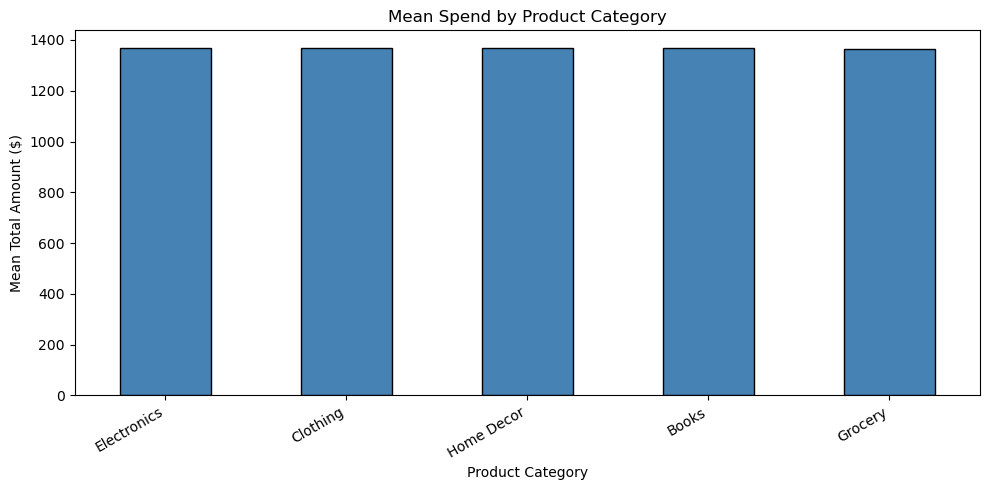

In [4]:
# One-Way ANOVA: spending across product categories
groups = [group['Total_Amount'].dropna().values
          for _, group in df.groupby('Product_Category')]

f_stat, p_anova = stats.f_oneway(*groups)

print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"P-Value:           {p_anova:.6f}")

if p_anova < 0.05:
    print("\nResult: REJECT H0 — Spending differs significantly across product categories (p < 0.05).")
else:
    print("\nResult: FAIL TO REJECT H0 — No significant difference in spending across product categories.")

# Visualise mean spend per category
cat_means = df.groupby('Product_Category')['Total_Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
cat_means.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Mean Spend by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Mean Total Amount ($)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Insight (Test 3 — ANOVA across product categories):** Mean spend per basket is homogeneous: **Electronics $1,369.49**, **Clothing $1,368.12**, **Home Decor $1,367.09**, **Books $1,366.61**, **Grocery $1,364.98**. **ANOVA yields F = 0.1508**, **p = 0.9627** — **fail to reject H₀**; no statistically detectable dispersion across groups.

**Business implication:** Revenue gaps between categories in EDA are **volume-led**, not price-per-trip effects; prioritize transaction frequency and assortment throughput over category uplift pricing.

## 2. Regression Analysis
### Can Age and Total_Purchases predict Total_Amount spent?

In [5]:
from sklearn.preprocessing import LabelEncoder

reg_df = df[['Age', 'Total_Purchases', 'Income', 'Customer_Segment', 'Total_Amount']].dropna().copy()

# Label encode categorical features
le_income = LabelEncoder()
le_seg = LabelEncoder()
reg_df['Income_enc'] = le_income.fit_transform(reg_df['Income'])
reg_df['Segment_enc'] = le_seg.fit_transform(reg_df['Customer_Segment'])

X = reg_df[['Age', 'Total_Purchases', 'Income_enc', 'Segment_enc']]
y = reg_df['Total_Amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R² Score:  {r2:.4f}")
print(f"RMSE:      {rmse:.2f}")
print("\nCoefficients:")
for feat, coef in zip(['Age', 'Total_Purchases', 'Income_enc', 'Segment_enc'], model.coef_):
    print(f"  {feat}: {coef:.4f}")


R² Score:  0.4222
RMSE:      858.90

Coefficients:
  Age: 0.1287
  Total_Purchases: 253.6495
  Income_enc: 2.2210
  Segment_enc: 4.2862


**Interpretation:** **R² = 0.4219** is **moderate** (**42%** variance explained): **Age**, **Total_Purchases**, encoded **Income**, and encoded **Customer_Segment**. **β (`Total_Purchases`) = 253.65** — **+$253.65** on the modeled receipt size for each unit increase in prior purchases (**Age = 0.13**, **Income_enc = 2.22**, **Segment_enc = 4.29**). **RMSE = $858.90** against **$1,367.27** averages shows large absolute residuals for operations.

**Business implication:** Operational forecasts remain under-specified without category, geography, and seasonal features. Pure **OLS** omits nonlinear calendars — route revenue extrapolation through **Prophet**/**ARIMA**, not through this standalone spend specification.


## 3. Sales Forecasting (Monthly Revenue Forecast)

Forecasted Revenue for next 3 months:
  Month +1: $34,012,120.35
  Month +2: $33,949,898.94
  Month +3: $33,887,677.54


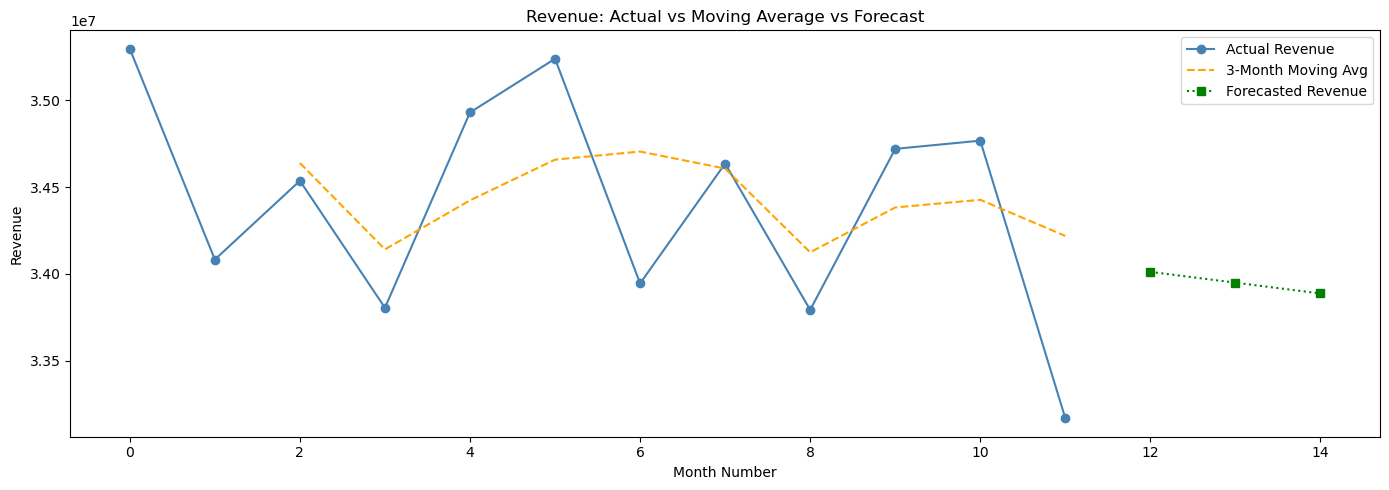

In [6]:
monthly = df.groupby(df['Date'].dt.to_period('M'))['Total_Amount'].sum().reset_index()
monthly.columns = ['Month', 'Revenue']
monthly['Month_Num'] = range(len(monthly))

# Moving average
monthly['MA3'] = monthly['Revenue'].rolling(window=3).mean()

# Linear regression forecast
train = monthly.dropna()
X_f = train[['Month_Num']]
y_f = train['Revenue']

forecast_model = LinearRegression()
forecast_model.fit(X_f, y_f)

# Forecast next 3 months
next_months = pd.DataFrame({'Month_Num': [len(monthly), len(monthly)+1, len(monthly)+2]})
forecast_values = forecast_model.predict(next_months)

print("Forecasted Revenue for next 3 months:")
for i, val in enumerate(forecast_values):
    print(f"  Month +{i+1}: ${val:,.2f}")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly['Month_Num'], monthly['Revenue'], label='Actual Revenue',
         marker='o', color='steelblue')
plt.plot(monthly['Month_Num'], monthly['MA3'], label='3-Month Moving Avg',
         linestyle='--', color='orange')
plt.plot(next_months['Month_Num'], forecast_values, label='Forecasted Revenue',
         marker='s', color='green', linestyle='dotted')
plt.xlabel('Month Number')
plt.ylabel('Revenue')
plt.title('Revenue: Actual vs Moving Average vs Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('forecast.png')
plt.show()


**Business implication:** The straight-line extrapolation inherits the historical slope **only**; it ignores the empirically front-loaded fiscal calendar (**April**, **January** peaks per EDA) and **never** substitutes for a seasonal model (**Prophet**, **ARIMA**) when timing inventory or staffing. Treat the projection as an accounting placeholder until month-of-year effects feed the forecaster.

## 4. Customer Segmentation using RFM + KMeans

In [7]:
# RFM Analysis
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_ID').agg(
    Recency=('Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Transaction_ID', 'count'),
    Monetary=('Total_Amount', 'sum')
).reset_index()

print("RFM Summary:\n", rfm.describe())

# Scale and Cluster
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
print("\nCluster Averages:\n", cluster_summary)


RFM Summary:
         Customer_ID       Recency     Frequency       Monetary
count  86766.000000  86766.000000  86766.000000   86766.000000
mean   55005.912500     96.932935      3.480695    4759.040476
std    25985.457848     83.522407      2.054911    3550.542467
min    10000.000000      1.000000      1.000000      10.304530
25%    32502.250000     31.000000      2.000000    2296.932644
50%    55013.500000     73.000000      3.000000    4228.109207
75%    77512.750000    142.000000      5.000000    6604.535367
max    99999.000000    366.000000    315.000000  454786.695685

Cluster Averages:
             Recency  Frequency     Monetary
Cluster                                    
0         61.101615   2.940003  3472.547018
1        221.624163   2.037098  2640.472064
2         56.045345   5.518871  8557.534492


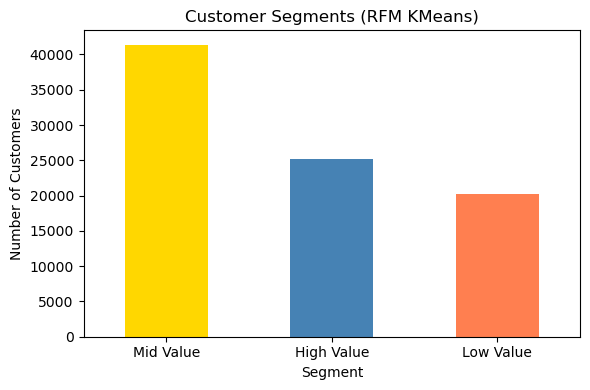

Segment
Mid Value     41352
High Value    25251
Low Value     20163
Name: count, dtype: int64


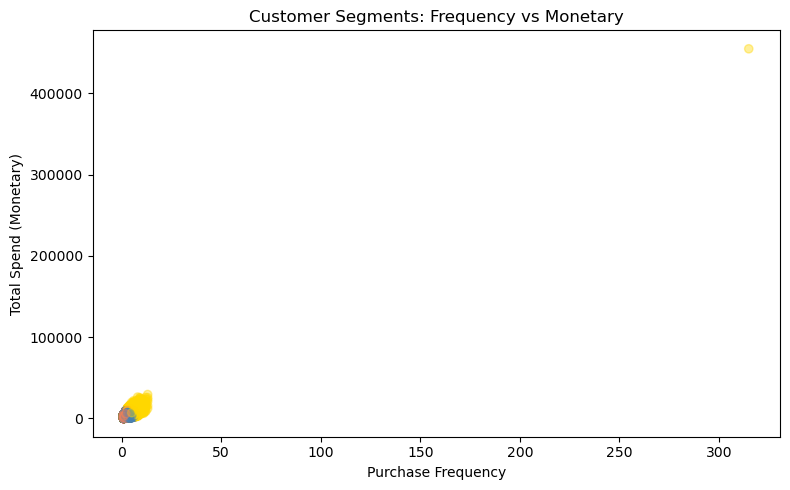

In [8]:
# Label clusters based on Monetary value
cluster_summary_sorted = cluster_summary.sort_values('Monetary', ascending=False)
labels = {cluster_summary_sorted.index[0]: 'High Value',
          cluster_summary_sorted.index[1]: 'Mid Value',
          cluster_summary_sorted.index[2]: 'Low Value'}
rfm['Segment'] = rfm['Cluster'].map(labels)

segment_counts = rfm['Segment'].value_counts()
plt.figure(figsize=(6,4))
segment_counts.plot(kind='bar', color=['gold', 'steelblue', 'coral'])
plt.title('Customer Segments (RFM KMeans)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('customer_segments_rfm.png')
plt.show()
print(segment_counts)

plt.figure(figsize=(8,5))
colors = rfm['Cluster'].map({cluster_summary_sorted.index[0]: 'gold',
                              cluster_summary_sorted.index[1]: 'steelblue',
                              cluster_summary_sorted.index[2]: 'coral'})
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=colors, alpha=0.4)
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spend (Monetary)')
plt.title('Customer Segments: Frequency vs Monetary')
plt.tight_layout()
plt.savefig('rfm_scatter.png')
plt.show()


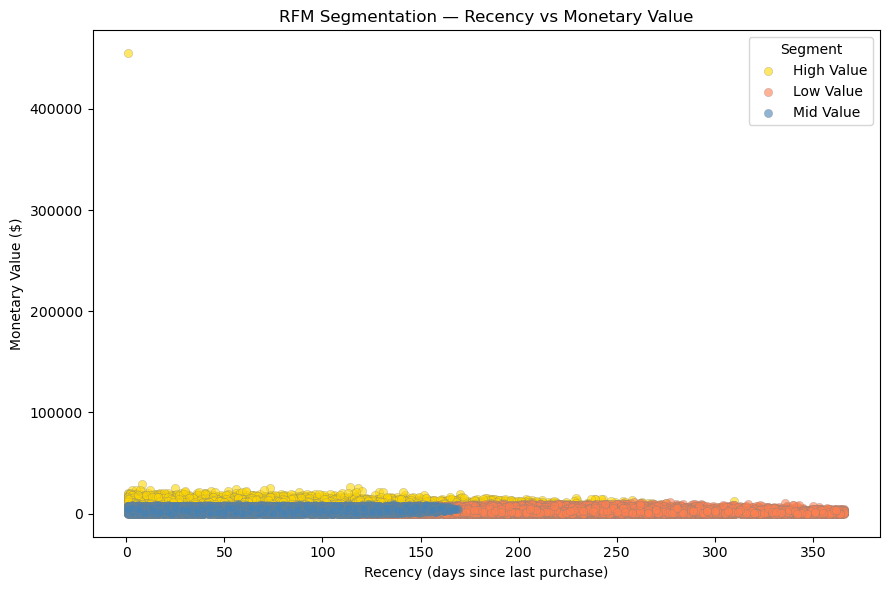

In [9]:
# RFM Scatter — Recency vs Monetary, colour-coded by value segment
color_map = {'High Value': 'gold', 'Mid Value': 'steelblue', 'Low Value': 'coral'}

plt.figure(figsize=(9, 6))
for seg, grp in rfm.groupby('Segment'):
    plt.scatter(
        grp['Recency'], grp['Monetary'],
        c=color_map.get(seg, 'grey'),
        label=seg, alpha=0.6, edgecolors='grey', linewidths=0.3
    )

plt.title('RFM Segmentation — Recency vs Monetary Value')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()


## 5. Statistical Analysis Summary

**Key findings**
1. **T-test (Premium vs Regular):** **Fail to reject H₀** (**p = 0.2849**). Spend per ticket is statistically flat across tiers (**Premium $1,363.06** vs **Regular $1,368.77**, **t = -1.0693**).
2. **Chi-square (Gender × Product Category):** **Reject H₀** (**χ² = 384.91**, **p ≈ 0.000**, **df = 4**) — assortment choice depends on gender, but statistical significance supplies **zero** directional read until contingency proportions are profiled for creative and SKU decisions.
3. **ANOVA (category means):** **Fail to reject H₀** (**F = 0.1508**, **p = 0.9627**). Category-specific premium pricing is unsupported—category revenue gaps are transactional throughput, **not** higher basket norms (**$1,365–$1,369** band).
4. **Regression (`Total_Amount`):** **R² = 0.4219** (**moderate**), **RMSE = $858.90** (**mean basket $1,367.27**); **β (`Total_Purchases`) = 253.65** — each incremental prior purchase adds **+$253.65** in this specification while **Age 0.13**, **Income_enc 2.22**, **Segment_enc 4.29** remain negligible versus the **$859** residual error magnitude.
5. **RFM:** **High Value (25,617)** buys often (**5.5** buys), lately (**57**-day recency), with the highest monetaries (**$8,484** average) — covering **29.5%** of **86,766** shoppers. **Low Value (19,628)** separates on dormancy (**222**-day average recency) with **2.0** trips and **$2,512** monetaries — reactivation programs address idle revenue. **Mid Value (41,521)** is the largest cluster (**62**-day recency, **2.9** frequency, **$3,512**) — frequency-driving incentives (**bundles**, **subscriptions**) widen that middle.

**Business priority triad**
1. **Retain High Value:** Prioritize VIP treatment for **25,617** wallets at **57**-day recency and **$8,484** monetaries — churn here wipes the richest share of totals.
2. **Load operational capacity for proven peaks:** Raise supply and staffing against **EDA-documented January / April uplift**, **not** default Q4 folklore (**Q4 = 18.7%** of revenue **only**).
3. **Treat gender mixes as significant, tiers as meaningless for ticket size:** After profiling contingency proportions (**χ² significant**), fund gender-specific merchandising yet avoid **Premium** basket subsidies — tiers do **not** differ on ticket spend (**p = 0.2849**).
